# Project 3: Classification__

### __Objective__
In this lab, you will apply supervised learning (classification) models to predict one of the following
1. **Loan Approval Outcomes** : The dataset includes demographic, financial, and credit history features of loan applicants.
2. **Airline Passenger Satisfaction** : Customer satisfaction scores from 120,000+ airline passengers, including additional information about each passenger, their flight, and type of travel, as well as ther evaluation of different factors like cleanliness, comfort, service, and overall experience.
3. **Hotel Booking Cancellations** : booking information for a city hotel and a resort hotel, and includes information such as when the booking was made, length of stay, the number of adults, children, and/or babies, and the number of available parking spaces, among other things

### __Requirements__
Your task is to explore the data, clean and preprocess it appropriately, and build predictive models. Specifically, you must:
1. **Perform EDA**: Explore distributions, identify missing values, and check for class imbalance in the target variable.
2. **Preprocess the Data**: Handle categorical encodings, impute missing values, and scale your features. *Hint: Make sure to perform your train-test split BEFORE scaling to prevent data leakage!*
3. **Train Classification Models**: train **two** classification models (**Logistic Regression** and **KNN**).
5. **Evaluate & Compare**: Evaluate models using accuracy, precision, recall, F1-score, and confusion matrices. 

### __Deliverables__
You are expected to document your workflow using Markdown cells. Do not just write code; explain your **rationale**. Include insights from your EDA, justify your preprocessing decisions, and conclude with a comparative analysis discussing which of the three models performed best and why.

---

## __Data Dictionary__

### Loan Approval Dataset
| Column                           | Description                                             | 
|----------------------------------|---------------------------------------------------------|
| person_age                       | Age of the person                                       |
| person_gender                    | Gender of the person                                    |
| person_education                 | Highest education level                                 |
| person_income                    | Annual income                                           | 
| person_emp_exp                   | Years of employment experience                          | 
| person_home_ownership            | Home ownership status (e.g., rent, own, mortgage)       | 
| loan_amnt                        | Loan amount requested                                   |
| loan_intent                      | Purpose of the loan                                     | 
| loan_int_rate                    | Loan interest rate                                      | 
| loan_percent_income              | Loan amount as a percentage of annual income            | 
| cb_person_cred_hist_length       | Length of credit history in years                       |
| credit_score                     | Credit score of the person                              |
| previous_loan_defaults_on_file   | Indicator of previous loan defaults                     |
| loan_status (target variable)    | Loan approval status: 1 = approved; 0 = rejected        |

## Setup and Data Loading
Import your libraries and load the dataset.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add your sklearn imports here...
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.metrics import roc_auc_score

In [2]:
# Load the dataset
loan = pd.read_csv('data/loan_data.csv')
loan.head()

,Unnamed: 0,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,0,22.0,female,MASTER,$71948.0,0,RENT,35000.0$,personal,16.02,0.49,3.0,561,No,1
1,1,21.0,female,High School,12282.0$,0,OWN,$1000.0,EDUCATION,11.14,0.08,2.0,504,yes,0
2,2,25.0,female,High School,12438.0$,3,MORTGAGE,$5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,3,23.0,female,Bachelor,$79753.0,0,RENT,$35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,4,24.0,MALE,Master,66135.0$,1,RENT,$35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


A few things immediately stand out:
- `person_income` and `loan_amnt` have dollar signs (`$`) mixed in — they're being read as text instead of numbers
- Some columns have inconsistent capitalization (e.g. `"MALE"` vs `"male"` vs `"Male"`)
- There's an unnamed index column we don't need

## Part 1: Exploratory Data Analysis (EDA)
* What insights did you gain from your EDA? Are there missing values? Outliers? Is the target variable balanced or imbalanced? Use visualizations to support your findings.

In [4]:
loan.shape

(47250, 15)

In [5]:
loan.dtypes

Unnamed: 0                          int64
person_age                        float64
person_gender                         str
person_education                      str
person_income                         str
person_emp_exp                      int64
person_home_ownership                 str
loan_amnt                             str
loan_intent                           str
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file        str
loan_status                         int64
dtype: object

Some numerical columns are stored as String

In [6]:
loan = loan.drop(columns=['Unnamed: 0']) #dropped the unnamed index column

In [7]:
loan.describe()

,person_age,person_emp_exp,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,47250.000000,47250.000000,47250.000000,47250.000000,47250.000000,47250.000000,47250.000000
mean,27.752550,5.398921,11.010191,0.139940,5.862222,632.586709,0.221947
std,6.032801,6.051270,2.981758,0.087238,3.873836,50.462422,0.415560
min,20.000000,0.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,1.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,4.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,8.000000,13.020000,0.190000,8.000000,670.000000,0.000000
max,144.000000,125.000000,20.000000,0.660000,30.000000,850.000000,1.000000


- person_age has a maximum value of 144, no human lives that long.
- person_emp_exp has a maximum of 125 years, which is also impossible, that's more years than most people are alive.
- person_income does not appear in the numerical summary because it is stored as text rather than numeric.

In [8]:
loan.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

Good news — there are **zero missing values** in the dataset.

In [9]:
loan['person_gender'].value_counts()

person_gender
female    21174
male      18253
MALE       7823
Name: count, dtype: int64

In [10]:
loan['loan_intent'].value_counts()

loan_intent
MEDICAL                8981
VENTURE                8210
EDUCATION              6735
PERSONAL               5576
DEBTCONSOLIDATION      5230
HOMEIMPROVEMENT        4999
 EDUCATION             2887
personal               2390
 DEBTCONSOLIDATION     2242
Name: count, dtype: int64

In [11]:
loan['person_education'].value_counts()

person_education
Associate        12612
Bachelor          9896
High School       8780
Master            5117
 Bachelor         4241
 High School      3763
MASTER            2193
Doctorate          648
Name: count, dtype: int64

In [12]:
loan['person_home_ownership'].value_counts()

person_home_ownership
RENT        24593
MORTGAGE    13599
mortgage     5828
OWN          2173
own           931
OTHER         126
Name: count, dtype: int64

In [13]:
loan['previous_loan_defaults_on_file'].value_counts()

previous_loan_defaults_on_file
Yes     16770
No      16305
yes      7187
 No      6988
Name: count, dtype: int64

In [14]:
loan['previous_loan_defaults_on_file'].value_counts()

previous_loan_defaults_on_file
Yes     16770
No      16305
yes      7187
 No      6988
Name: count, dtype: int64

**Mixed capitalisation and extra spaces found across all categorical columns.**

Fix: strip whitespace and convert everything to upper case so each category has exactly one form.

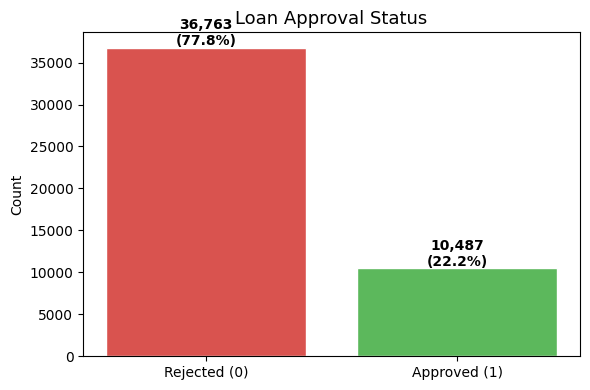

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = loan['loan_status'].value_counts()
ax.bar(['Rejected (0)', 'Approved (1)'], counts.values, color=['#d9534f', '#5cb85c'], edgecolor='white')
for i, v in enumerate(counts.values):
    ax.text(i, v + 300, f'{v:,}\n({v/len(loan)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Loan Approval Status', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

> **There is a significant class imbalance.**

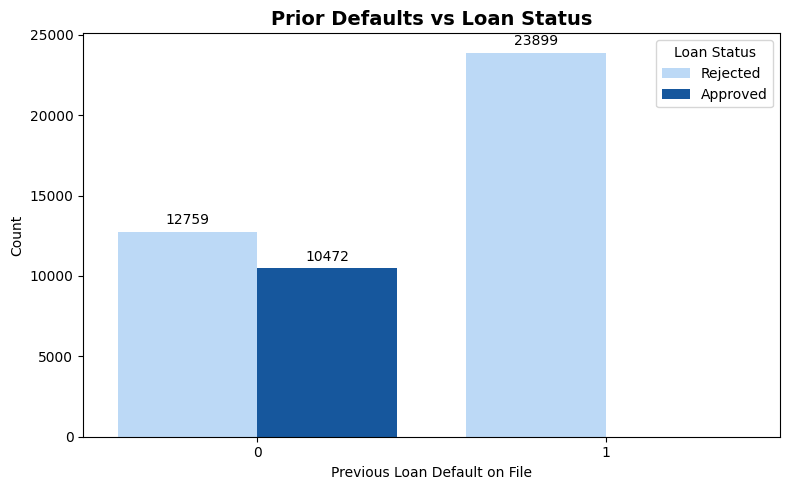

Chart saved as 'default_vs_approval.png'


In [74]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=loan,
    x='previous_loan_defaults_on_file',
    hue='loan_status',
    palette=['#B3D9FF', '#0056B3']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Prior Defaults vs Loan Status', fontsize=14, fontweight='bold')
plt.xlabel('Previous Loan Default on File')
plt.ylabel('Count')
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])

plt.tight_layout()
plt.show()

fig.savefig(
    'default_vs_approval.png',
    dpi=300,
    bbox_inches='tight',
    transparent=True
)

print("Chart saved as 'default_vs_approval.png'")

In [17]:
cat_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']

for col in cat_cols:
    loan[col] = loan[col].str.strip().str.upper()

for col in cat_cols:
    print(f"{col}: {loan[col].unique()}")

person_gender: <StringArray>
['FEMALE', 'MALE']
Length: 2, dtype: str
person_education: <StringArray>
['MASTER', 'HIGH SCHOOL', 'BACHELOR', 'ASSOCIATE', 'DOCTORATE']
Length: 5, dtype: str
person_home_ownership: <StringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str
loan_intent: <StringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str
previous_loan_defaults_on_file: <StringArray>
['NO', 'YES']
Length: 2, dtype: str


Fixed inconsistencies

In [18]:
loan['person_income'] = (loan['person_income'].astype(str).str.replace('$', '', regex=False).str.strip().astype(float))
loan['loan_amnt'] = (loan['loan_amnt'].astype(str).str.replace('$', '', regex=False).str.strip().astype(float))

In [19]:
loan.dtypes

person_age                        float64
person_gender                         str
person_education                      str
person_income                     float64
person_emp_exp                      int64
person_home_ownership                 str
loan_amnt                         float64
loan_intent                           str
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file        str
loan_status                         int64
dtype: object

Converted and fixed person_income and loan_amnt to float

In [20]:
loan = loan[loan['person_age'] <= 70]
loan = loan[loan['person_emp_exp'] <= 60]

loan.shape

(47234, 14)

Removed rows with impossible age (>70) and employment experience (>60)

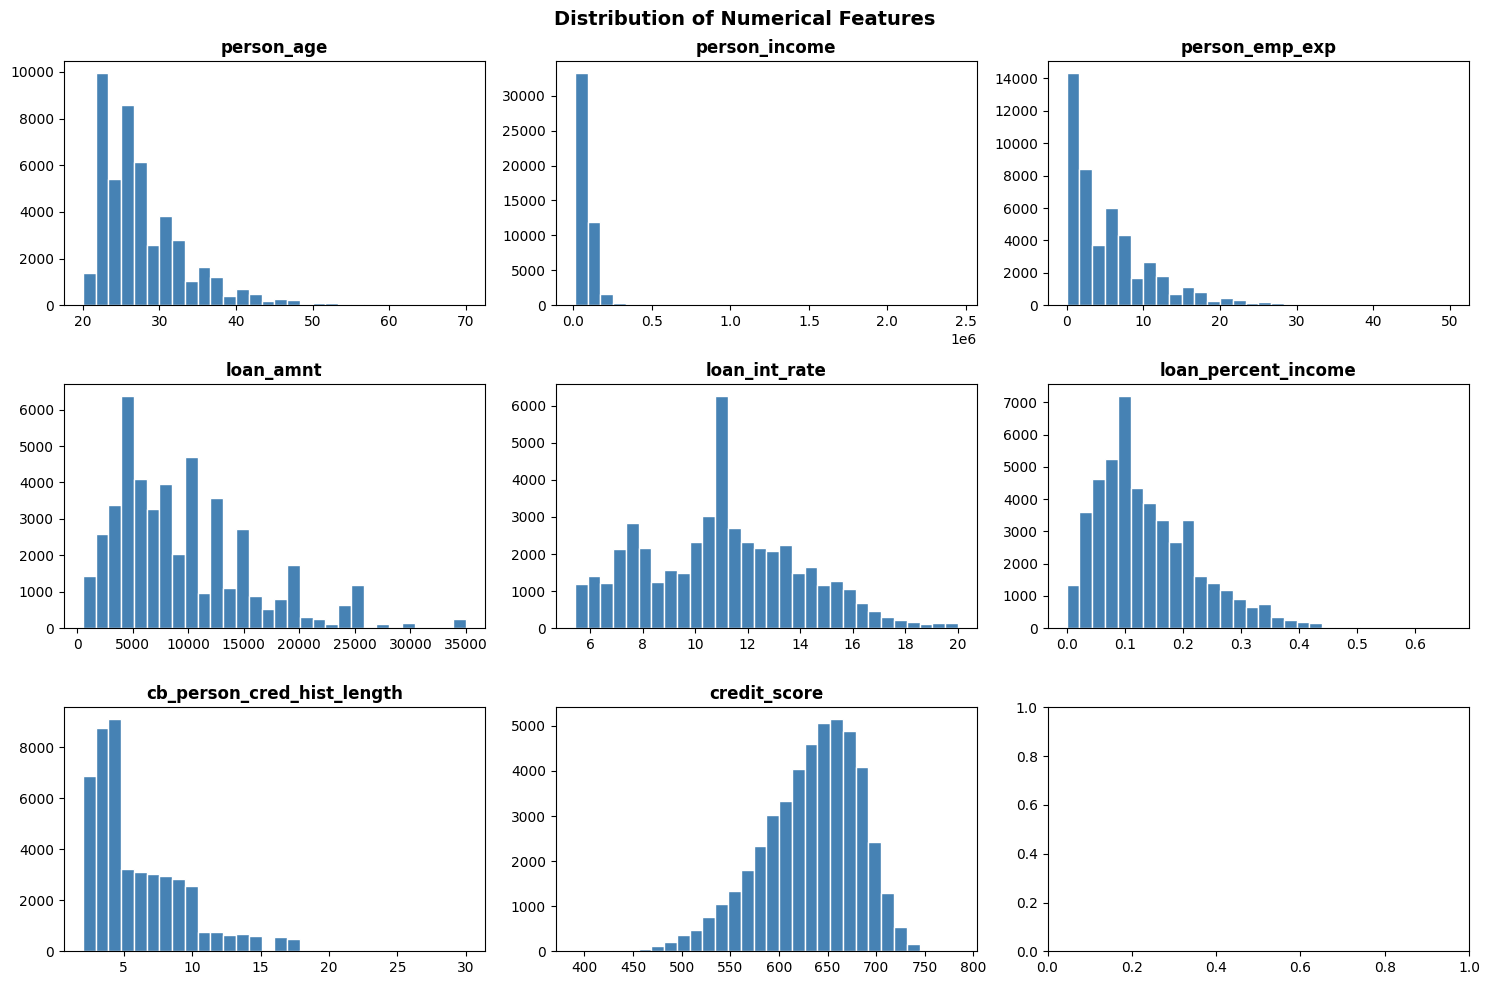

In [21]:
num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(loan[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

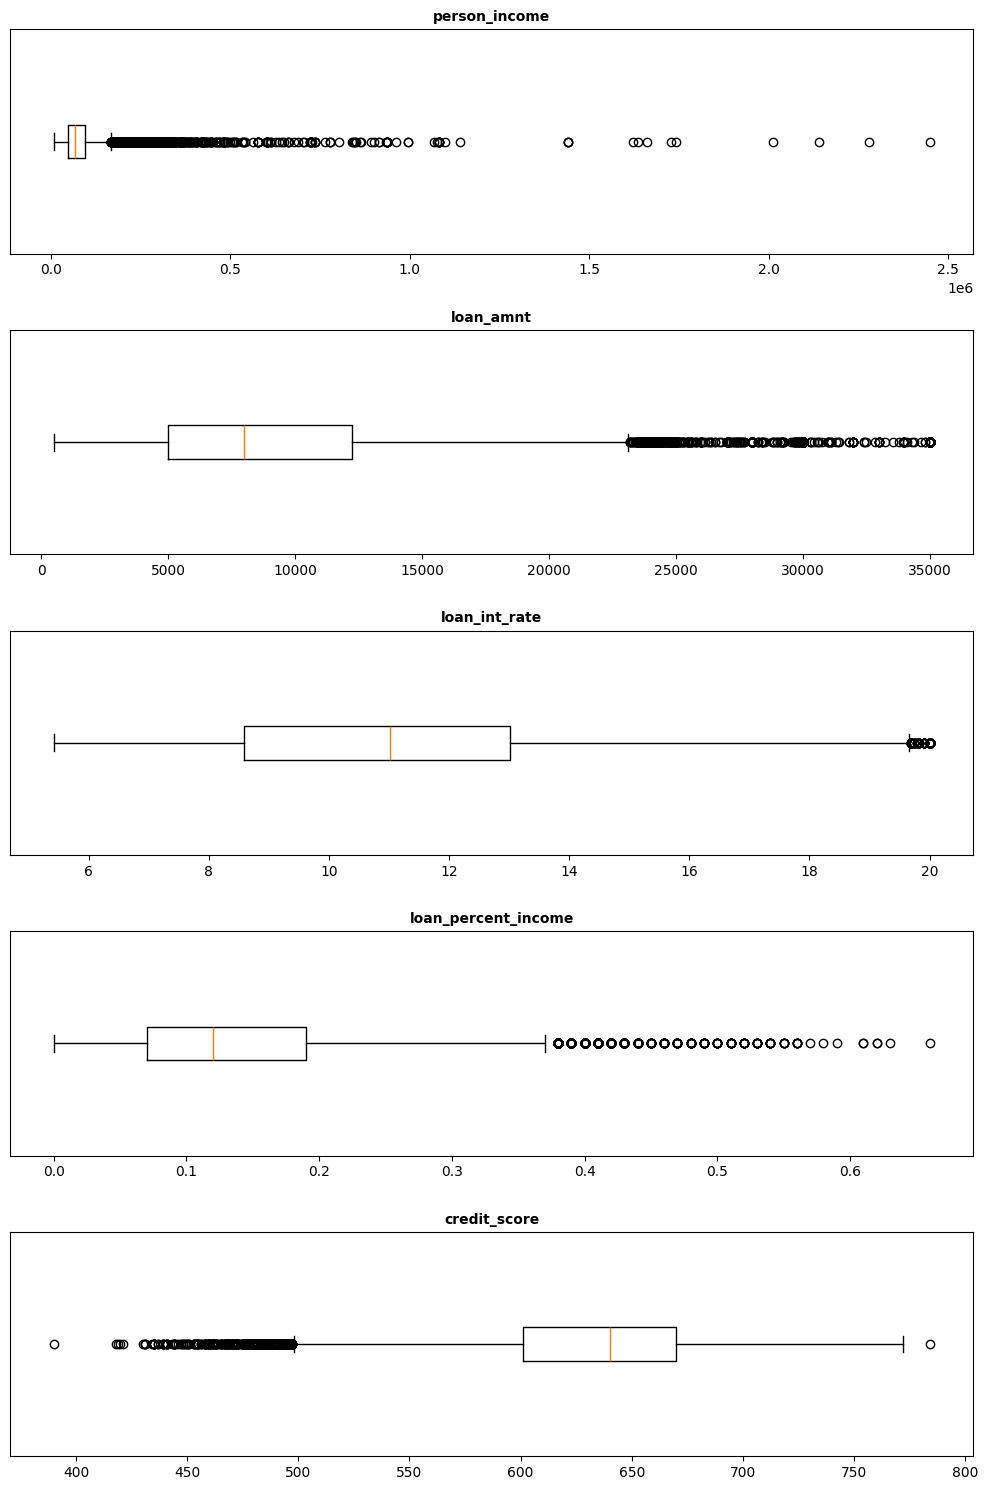

In [22]:
outlier_chack = ['person_income', 'loan_amnt', 'loan_int_rate', 
                 'loan_percent_income', 'credit_score']

fig, axes = plt.subplots(len(outlier_chack), 1, figsize=(10, 15))

for ax, col in zip(axes, outlier_chack):
    ax.boxplot(loan[col].dropna(), vert=False)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_yticks([])

plt.tight_layout()
plt.show()

### check if the data is reasonable

In [23]:
invalid_exp = loan[loan['person_emp_exp'] > loan['person_age']]

print(f"Invalid rows: {len(invalid_exp)}")
print(invalid_exp[['person_age', 'person_emp_exp']].head())

Invalid rows: 0
Empty DataFrame
Columns: [person_age, person_emp_exp]
Index: []


In [24]:
invalid_credit = loan[
    loan['cb_person_cred_hist_length'] > loan['person_age']
]

print(f"Invalid rows: {len(invalid_credit)}")
print(
    invalid_credit[
        ['person_age', 'cb_person_cred_hist_length']
    ].head()
)

Invalid rows: 0
Empty DataFrame
Columns: [person_age, cb_person_cred_hist_length]
Index: []


In [25]:
invalid_exp_realistic = loan[
    loan['person_emp_exp'] > (loan['person_age'] - 18)
]

print(f"Suspicious rows: {len(invalid_exp_realistic)}")
print(
    invalid_exp_realistic[
        ['person_age', 'person_emp_exp']
    ].head()
)

Suspicious rows: 0
Empty DataFrame
Columns: [person_age, person_emp_exp]
Index: []


In [26]:
invalid_credit_realistic = loan[
    loan['cb_person_cred_hist_length'] > (loan['person_age'] - 16)
]

print(f"Suspicious rows: {len(invalid_credit_realistic)}")
print(
    invalid_credit_realistic[
        ['person_age', 'cb_person_cred_hist_length']
    ].head()
)

Suspicious rows: 0
Empty DataFrame
Columns: [person_age, cb_person_cred_hist_length]
Index: []


In [27]:
print((loan['person_income'] > 500000).sum())
loan = loan[loan['person_income'] <= 500000]
loan.shape

104


(47130, 14)

### see the relationship between features

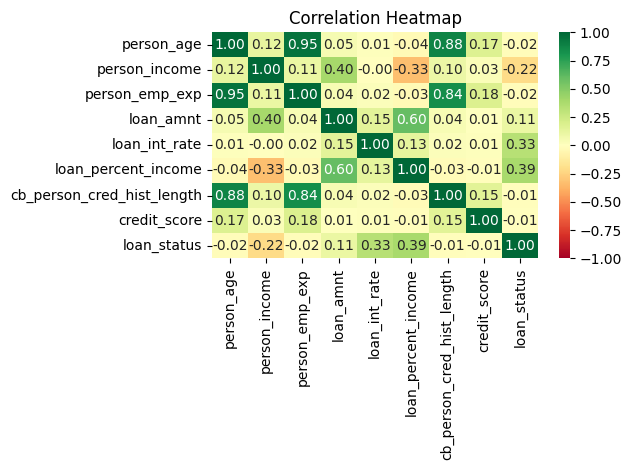

In [28]:
num_features = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
                'credit_score', 'loan_status']

sns.heatmap(loan[num_features].corr(), annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [29]:
corr_matrix = loan.corr(numeric_only=True)
print(corr_matrix)

                            person_age  person_income  person_emp_exp  \
person_age                    1.000000       0.119738        0.951253   
person_income                 0.119738       1.000000        0.107693   
person_emp_exp                0.951253       0.107693        1.000000   
loan_amnt                     0.051126       0.398298        0.044432   
loan_int_rate                 0.012698      -0.000098        0.015668   
loan_percent_income          -0.036866      -0.330577       -0.033464   
cb_person_cred_hist_length    0.878198       0.100324        0.839163   
credit_score                  0.172632       0.025399        0.180403   
loan_status                  -0.018846      -0.215678       -0.017775   

                            loan_amnt  loan_int_rate  loan_percent_income  \
person_age                   0.051126       0.012698            -0.036866   
person_income                0.398298      -0.000098            -0.330577   
person_emp_exp               0.044432 

#### No single feature has a strong correlation with loan_status, the highest is around 0.4. The model needs to combine multiple signals to make a good prediction. Also, person_age and person_emp_exp are correlated with each other, which makes sense.. older people tend to have more work experience.

In [30]:
### because of strong correlation  between some features we will do (Variance Inflation Factor):

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = loan[['person_age',
        'person_emp_exp',
        'cb_person_cred_hist_length',
        'loan_int_rate',
        'loan_percent_income',
        'credit_score']]

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

                      feature         VIF
0                  person_age  156.302538
1              person_emp_exp   11.351971
2  cb_person_cred_hist_length   13.329391
3               loan_int_rate   14.363005
4         loan_percent_income    3.629675
5                credit_score   92.554756


## Part 2: Data Preprocessing
* Explain your strategy for handling categorical variables (e.g., One-Hot Encoding vs Label Encoding) and missing data.  
**Crucial:** Remember to split your data into training and testing sets BEFORE applying scaling to prevent data leakage.

In [32]:
# Your preprocessing, train_test_split, and scaling code here
# Note: you are not required to answer in this single cell, create more cells if needed


In [33]:
for col in cat_cols:
    loan[col] = loan[col].str.strip().str.lower()
 

for col in cat_cols:
    print(f"\n{col}: {loan[col].unique()}")


person_gender: <StringArray>
['female', 'male']
Length: 2, dtype: str

person_education: <StringArray>
['master', 'high school', 'bachelor', 'associate', 'doctorate']
Length: 5, dtype: str

person_home_ownership: <StringArray>
['rent', 'own', 'mortgage', 'other']
Length: 4, dtype: str

loan_intent: <StringArray>
[         'personal',         'education',           'medical',
           'venture',   'homeimprovement', 'debtconsolidation']
Length: 6, dtype: str

previous_loan_defaults_on_file: <StringArray>
['no', 'yes']
Length: 2, dtype: str


### Label encode binary variables

In [34]:
loan['person_gender'] = LabelEncoder().fit_transform(loan['person_gender'])

In [35]:
loan['previous_loan_defaults_on_file'] = loan['previous_loan_defaults_on_file'].map({'no': 0, 'yes': 1})

### label encoding for person_education is ordinal, because the category has a natural order.

In [36]:
education_order = {'high school': 0, 'associate': 1, 'bachelor': 2, 'master': 3, 'doctorate': 4}
loan['person_education'] = loan['person_education'].map(education_order)

### hot incoding for 'person_home_ownership', 'loan_intent' because they has no order

In [37]:
#loan = pd.get_dummies(loan, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

loan = pd.get_dummies(
    loan,
    columns=['person_home_ownership', 'loan_intent'],
    drop_first=True,
    dtype=int
)

In [1]:
loan.head(10)

NameError: name 'loan' is not defined

In [39]:
loan.to_csv('loan_data_cleaned.csv', index=False)

In [40]:
X = loan.drop(columns=['loan_status'])
y = loan['loan_status']

In [41]:
print(y.value_counts())

loan_status
0    36658
1    10472
Name: count, dtype: int64


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [44]:
results = []

In [85]:
loan.shape

(47130, 20)

## Part 3: Modeling
* We now train our two baseline models using default settings.
These serve as our starting point — a benchmark to compare against
once we apply tuning later.

### Model 1 base : Logistic Regression 

In [45]:
lr_base = LogisticRegression(random_state=42, max_iter=1000)
lr_base.fit(X_train_scaled, y_train)
lr_base_pred = lr_base.predict(X_test_scaled)

### Model 2 base : KNN

In [46]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)
knn_base_pred = knn_base.predict(X_test_scaled)

## Part 4: Evaluation
* Output the classification reports and confusion matrices for all models.

In [47]:
# Evaluation metrics
# Note: you are not required to answer in this single cell, create more cells if needed


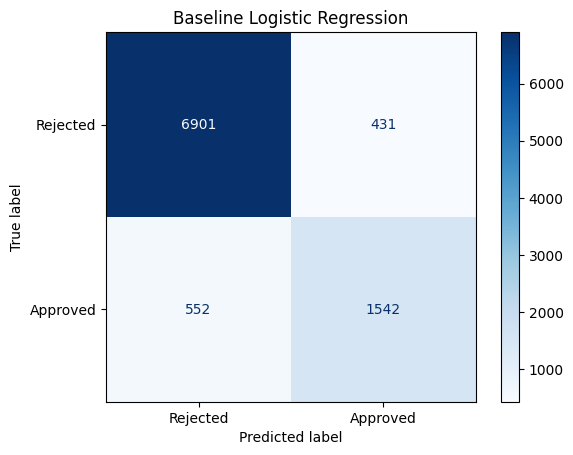

Accuracy:  0.8957
Precision: 0.7816
Recall / Sensitivity / True Positive Rate (TPR): 0.7364
Specificity / True Negative Rate (TNR): 0.9412
F1 Score:  0.7583


In [48]:
cm = confusion_matrix(y_test, lr_base_pred)
ConfusionMatrixDisplay(cm, display_labels=['Rejected', 'Approved']).plot(cmap='Blues')
plt.title('Baseline Logistic Regression')
plt.show()

print(f'Accuracy:  {accuracy_score(y_test, lr_base_pred):.4f}')
print(f'Precision: {precision_score(y_test, lr_base_pred):.4f}')
print(f'Recall / Sensitivity / True Positive Rate (TPR): {recall_score(y_test, lr_base_pred):.4f}')
specificity = recall_score(y_test, lr_base_pred, pos_label=0)
print(f'Specificity / True Negative Rate (TNR): {specificity:.4f}')
print(f'F1 Score:  {f1_score(y_test, lr_base_pred):.4f}')

results.append({
    'Model':     'Baseline Logistic Regression',
    'Accuracy':  accuracy_score(y_test, lr_base_pred),
    'Precision': precision_score(y_test, lr_base_pred),
    'Recall':    recall_score(y_test, lr_base_pred),
    'F1':        f1_score(y_test, lr_base_pred)
})

**The model got most rejections right (6,901 out of 7,332). Where it struggled was with 
approvals: it missed 552 people who should have been approved and approved 
to 431 who should have been rejected.**

**Accuracy of 89.6% looks strong but is misleading given the 78/22 class split. The more honest 
metrics are Precision (78.2%) and Recall (73.6%), meaning when it approved someone it was right 
78% of the time, but it still left 552 applicants that should've been approved rejected. F1 of 75.8% reflects 
that balance. The specificity of 94.1% tells us it's very good at correctly identifying 
rejections which makes sense since rejections dominate the dataset.**

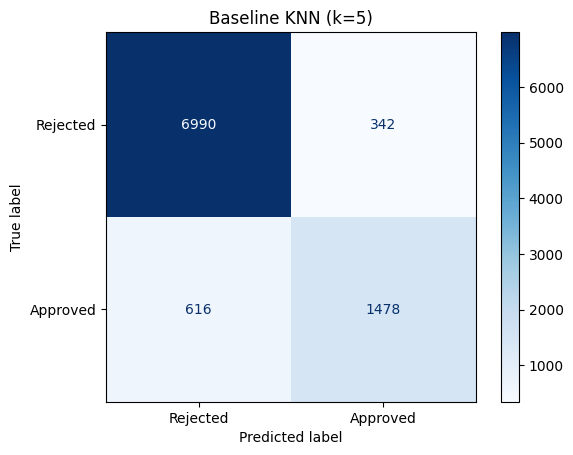

Accuracy:  0.8984
Precision: 0.8121
Recall / Sensitivity / True Positive Rate (TPR): 0.7058
Specificity / True Negative Rate (TNR): 0.9534
F1 Score:  0.7552


In [49]:
cm = confusion_matrix(y_test, knn_base_pred)
ConfusionMatrixDisplay(cm, display_labels=['Rejected', 'Approved']).plot(cmap='Blues')
plt.title('Baseline KNN (k=5)')
plt.show()

print(f'Accuracy:  {accuracy_score(y_test, knn_base_pred):.4f}')
print(f'Precision: {precision_score(y_test, knn_base_pred):.4f}')
print(f'Recall / Sensitivity / True Positive Rate (TPR): {recall_score(y_test, knn_base_pred):.4f}')
specificity = recall_score(y_test, knn_base_pred, pos_label=0)
print(f'Specificity / True Negative Rate (TNR): {specificity:.4f}')
print(f'F1 Score:  {f1_score(y_test, knn_base_pred):.4f}')

results.append({
    'Model':     'Baseline KNN (k=5)',
    'Accuracy':  accuracy_score(y_test, knn_base_pred),
    'Precision': precision_score(y_test, knn_base_pred),
    'Recall':    recall_score(y_test, knn_base_pred),
    'F1':        f1_score(y_test, knn_base_pred)
})

**Baseline KNN correctly approved 1,478 applicants and correctly rejected 6,990. It had fewer 
false approvals than LR (342 vs 431) but missed more genuine approvals (616 vs 552).**

**This tradeoff shows up clearly in the metrics, Precision is higher at 81.2% (more careful 
about who it approves) but Recall dropped to 70.6% (left more creditworthy applicants behind). 
The F1 of 75.5% is slightly below LR, meaning the gains in precision didn't fully compensate 
for the drop in recall. Specificity of 95.3% is the highest so far.. KNN is very conservative, 
which isn't always a good thing in lending.**

**Overall both baseline models perform similarly. KNN is more precise but LR catches more real 
approvals. Tuning will determine which approach holds up better with optimal settings.**

# Model Improving

## Improving the Models: GridSearchCV + Pipelines + Regularization

>  Note: Because the dataset is class-imbalanced (77.8% Rejected vs 22.2% Approved), we use class_weight='balanced' in Logistic Regression and StratifiedKFold in GridSearchCV to ensure each fold preserves the class ratio.

### Model 1 Improvment : Logistic Regression 

In [78]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=42,
        max_iter=1000             
    ))
])

lr_param_grid = {

    'model__C': [0.1, 0.5, 1, 5, 10],

    'model__penalty': ['l1', 'l2'],

    'model__solver': ['liblinear']
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

print("Best Parameters:", lr_grid.best_params_)
print(f"Best CV F1: {lr_grid.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Parameters: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV F1: 0.7627


**The baseline models used default settings. We now use GridSearchCV with a Pipeline to search 
for better hyperparameters. The Pipeline ensures scaling happens inside each cross-validation 
fold, not before it — this prevents data leakage. We use StratifiedKFold to preserve the 78/22 
class ratio in each fold, and optimise for F1 rather than accuracy.**

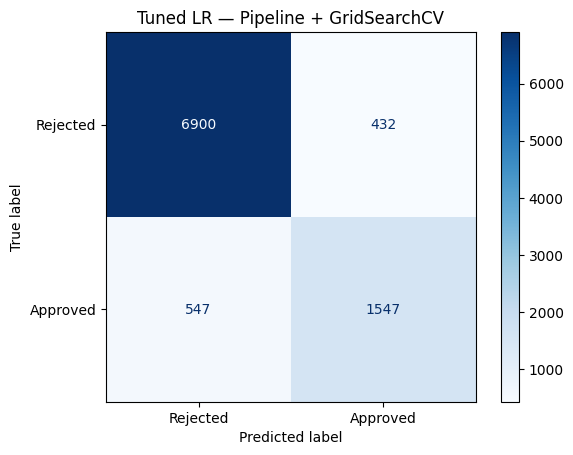

Accuracy: 0.8961
Precision: 0.7817
Recall: 0.7388
Specificity: 0.9411
F1 Score: 0.7596


In [80]:
lr_tuned_pred = lr_grid.best_estimator_.predict(X_test)

cm = confusion_matrix(y_test, lr_tuned_pred)
ConfusionMatrixDisplay(
    cm,
    display_labels=['Rejected', 'Approved']
).plot(cmap='Blues')

plt.title('Tuned LR — Pipeline + GridSearchCV')
plt.show()

print(f"Accuracy: {accuracy_score(y_test, lr_tuned_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_tuned_pred):.4f}")
print(f"Recall: {recall_score(y_test, lr_tuned_pred):.4f}")
print(f"Specificity: {recall_score(y_test, lr_tuned_pred, pos_label=0):.4f}")
print(f"F1 Score: {f1_score(y_test, lr_tuned_pred):.4f}")

results.append({
    'Model': 'Tuned LR (GridSearchCV)',
    'Accuracy': accuracy_score(y_test, lr_tuned_pred),
    'Precision': precision_score(y_test, lr_tuned_pred),
    'Recall': recall_score(y_test, lr_tuned_pred),
    'F1': f1_score(y_test, lr_tuned_pred)
})

In [88]:
lr_results = pd.DataFrame([
    {
        'Model': 'Baseline LR',
        'Accuracy': accuracy_score(y_test, lr_base_pred),
        'Precision': precision_score(y_test, lr_base_pred),
        'Recall': recall_score(y_test, lr_base_pred),
        'Specificity': recall_score(y_test, lr_base_pred, pos_label=0),
        'F1': f1_score(y_test, lr_base_pred)
    },
    {
        'Model': 'Tuned LR',
        'Accuracy': accuracy_score(y_test, lr_tuned_pred),
        'Precision': precision_score(y_test, lr_tuned_pred),
        'Recall': recall_score(y_test, lr_tuned_pred),
        'Specificity': recall_score(y_test, lr_tuned_pred, pos_label=0),
        'F1': f1_score(y_test, lr_tuned_pred)
    }
]).set_index('Model')

lr_results.style \
    .highlight_max(axis=0, color='#C8F7C5') \
    .highlight_min(axis=0, color='#F7C5C5') \
    .format("{:.4f}") \
    .set_caption("Logistic Regression — Baseline vs Tuned") \
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('font-size', '14px'),
                ('font-weight', 'bold'),
                ('padding-bottom', '10px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#F0F0F0'),
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('text-align', 'center'),
                ('padding', '6px 12px')
            ]
        }
    ])

,Accuracy,Precision,Recall,Specificity,F1
Model,,,,,
Baseline LR,0.8957,0.7816,0.7364,0.9412,0.7583
Tuned LR,0.8961,0.7817,0.7388,0.9411,0.7596


**GridSearchCV tested 10 combinations across 5 folds (50 fits total) and found that C=1 with L2 
penalty works best. Interestingly this is close to the default settings, which explains why the 
improvement is small.**

**The confusion matrix barely changed; 1,547 correct approvals vs 1,542 in the baseline, and 
547 missed approvals vs 552. Precision held at 78.2%, Recall improved slightly to 73.9%, F1 
moved from 75.8% to 75.96%. The model was already near its ceiling with default settings 
tuning confirmed that rather than dramatically changing it.**

### Model 1 second improvment 

In [52]:
#tuned Logistic Regression 2 (Balanced Precision & Recall)

lr_tuned2_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ))
])

lr_tuned2_param_grid = {

    #wider search range
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],

    'model__penalty': ['l1', 'l2'],

    'model__solver': ['liblinear']
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_tuned2 = GridSearchCV(
    estimator=lr_tuned2_pipeline,
    param_grid=lr_tuned2_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

lr_tuned2.fit(X_train, y_train)

print("Best Parameters:", lr_tuned2.best_params_)
print(f"Best CV F1: {lr_tuned2.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best Parameters: {'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV F1: 0.7437


**The first tuned LR didn't change much from baseline. We try a second approach, we added
class_weight='balanced' to make the model pay more attention to the minority class (approvals), 
and widening the search range for C. The goal is to see if we can push recall higher, even if 
it costs us some precision.**

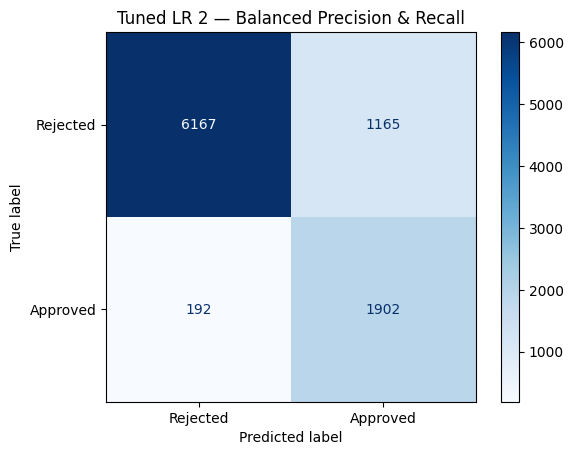

Accuracy:    0.8560
Precision:   0.6201
Recall:      0.9083
Specificity: 0.8411
F1 Score:    0.7371


In [53]:
#predict using the best pipeline
lr_tuned2_pred = lr_tuned2.best_estimator_.predict(X_test)

cm = confusion_matrix(y_test, lr_tuned2_pred)

ConfusionMatrixDisplay(
    cm,
    display_labels=['Rejected', 'Approved']
).plot(cmap='Blues')

plt.title('Tuned LR 2 — Balanced Precision & Recall')
plt.show()

print(f"Accuracy:    {accuracy_score(y_test, lr_tuned2_pred):.4f}")
print(f"Precision:   {precision_score(y_test, lr_tuned2_pred):.4f}")
print(f"Recall:      {recall_score(y_test, lr_tuned2_pred):.4f}")
print(f"Specificity: {recall_score(y_test, lr_tuned2_pred, pos_label=0):.4f}")
print(f"F1 Score:    {f1_score(y_test, lr_tuned2_pred):.4f}")

results.append({
    'Model':     'Tuned LR 2 (Balanced P&R)',
    'Accuracy':  accuracy_score(y_test, lr_tuned2_pred),
    'Precision': precision_score(y_test, lr_tuned2_pred),
    'Recall':    recall_score(y_test, lr_tuned2_pred),
    'F1':        f1_score(y_test, lr_tuned2_pred)
})

In [89]:
lr_results = pd.DataFrame([
    {
        'Model':       'Baseline LR',
        'Accuracy':    accuracy_score(y_test, lr_base_pred),
        'Precision':   precision_score(y_test, lr_base_pred),
        'Recall':      recall_score(y_test, lr_base_pred),
        'Specificity': recall_score(y_test, lr_base_pred, pos_label=0),
        'F1':          f1_score(y_test, lr_base_pred)
    },
    {
        'Model':       'Tuned LR 2 (Balanced P&R)',
        'Accuracy':    accuracy_score(y_test, lr_tuned2_pred),
        'Precision':   precision_score(y_test, lr_tuned2_pred),
        'Recall':      recall_score(y_test, lr_tuned2_pred),
        'Specificity': recall_score(y_test, lr_tuned2_pred, pos_label=0),
        'F1':          f1_score(y_test, lr_tuned2_pred)
    }
]).set_index('Model')

lr_results.style \
    .highlight_max(axis=0, color='#c8f7c5') \
    .highlight_min(axis=0, color='#f7c5c5') \
    .format("{:.4f}") \
    .set_caption("Logistic Regression — Baseline vs Tuned 2 (balancing between percision and recall") \
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'),
                   ('font-weight', 'bold'),
                   ('padding-bottom', '10px')]},
        {'selector': 'th',
         'props': [('background-color', '#f0f0f0'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('text-align', 'center'),
                   ('padding', '6px 12px')]}
    ])

,Accuracy,Precision,Recall,Specificity,F1
Model,,,,,
Baseline LR,0.8957,0.7816,0.7364,0.9412,0.7583
Tuned LR 2 (Balanced P&R),0.8961,0.7817,0.7388,0.9411,0.7596


**Best parameters came back as C=10 with L1 penalty. The shift is visible in the confusion matrix where correct approvals jumped from 1,547 to 1,902, and missed approvals dropped from 547 to just 
192. That's a significant improvement in recall (73.9% to 90.8%).**

**The tradeoff is precision dropped to 62.0% so the model is now approving 1,165 people who 
shouldn't be, up from 432. Accuracy also dipped to 85.6%.**

**Whether this version is "better" depends on the business priority. If missing a genuine approval 
is more costly than approving a risky applicant, this model wins. If the bank wants to be more 
conservative, the first tuned version is safer. F1 of 73.7% sits between both extremes.**

### Model 2 Improvments: :KNN 

In [83]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsClassifier())
])

knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 11, 15, 21],

    'model__weights': ['uniform', 'distance'],

    'model__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train, y_train)

print("Best Parameters:", knn_grid.best_params_)
print(f"Best CV F1:      {knn_grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'distance'}
Best CV F1:      0.7895


**For KNN, GridSearchCV tested 24 combinations across 5 folds (120 fits total). We searched 
across different values of k, distance metric, and weighting strategy. Unlike LR, KNN has 
no regularisation.. the tuning here is entirely about finding the right neighbourhood size 
and how to measure similarity between applicants.**

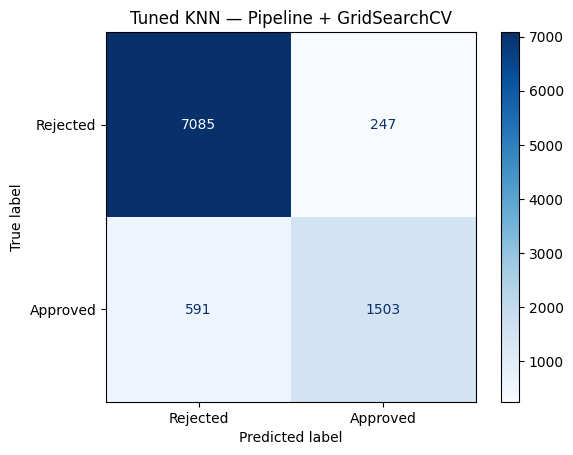

Accuracy:    0.9111
Precision:   0.8589
Recall:      0.7178
Specificity: 0.9663
F1 Score:    0.7820


In [55]:
knn_tuned_pred = knn_grid.best_estimator_.predict(X_test)

cm = confusion_matrix(y_test, knn_tuned_pred)
ConfusionMatrixDisplay(cm, display_labels=['Rejected', 'Approved']).plot(cmap='Blues')
plt.title('Tuned KNN — Pipeline + GridSearchCV')
plt.show()

print(f"Accuracy:    {accuracy_score(y_test, knn_tuned_pred):.4f}")
print(f"Precision:   {precision_score(y_test, knn_tuned_pred):.4f}")
print(f"Recall:      {recall_score(y_test, knn_tuned_pred):.4f}")
print(f"Specificity: {recall_score(y_test, knn_tuned_pred, pos_label=0):.4f}")
print(f"F1 Score:    {f1_score(y_test, knn_tuned_pred):.4f}")

results.append({
    'Model':     'Tuned KNN (GridSearchCV)',
    'Accuracy':  accuracy_score(y_test, knn_tuned_pred),
    'Precision': precision_score(y_test, knn_tuned_pred),
    'Recall':    recall_score(y_test, knn_tuned_pred),
    'F1':        f1_score(y_test, knn_tuned_pred)
})

In [90]:
knn_results = pd.DataFrame([
    {
        'Model':       'Baseline KNN',
        'Accuracy':    accuracy_score(y_test, knn_base_pred),
        'Precision':   precision_score(y_test, knn_base_pred),
        'Recall':      recall_score(y_test, knn_base_pred),
        'Specificity': recall_score(y_test, knn_base_pred, pos_label=0),
        'F1':          f1_score(y_test, knn_base_pred)
    },
    {
        'Model':       'Tuned KNN (GridSearchCV)',
        'Accuracy':    accuracy_score(y_test, knn_tuned_pred),
        'Precision':   precision_score(y_test, knn_tuned_pred),
        'Recall':      recall_score(y_test, knn_tuned_pred),
        'Specificity': recall_score(y_test, knn_tuned_pred, pos_label=0),
        'F1':          f1_score(y_test, knn_tuned_pred)
    }
]).set_index('Model')

knn_results.style \
    .highlight_max(axis=0, color='#c8f7c5') \
    .highlight_min(axis=0, color='#f7c5c5') \
    .format("{:.4f}") \
    .set_caption("KNN — Baseline vs Tuned") \
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'),
                   ('font-weight', 'bold'),
                   ('padding-bottom', '10px')]},
        {'selector': 'th',
         'props': [('background-color', '#f0f0f0'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('text-align', 'center'),
                   ('padding', '6px 12px')]}
    ])

,Accuracy,Precision,Recall,Specificity,F1
Model,,,,,
Baseline KNN,0.8984,0.8121,0.7058,0.9534,0.7552
Tuned KNN (GridSearchCV),0.9111,0.8589,0.7178,0.9663,0.7820


**Best settings: k=15, Manhattan distance, distance weighting. The improvement over baseline 
KNN is clear where false approvals dropped from 342 to 247, and the model still correctly 
approved 1,503 applicants.**

**Precision jumped to 85.9% (from 81.2%) and F1 improved to 78.2% (from 75.5%). Recall 
stayed around the same at 71.8%. Specificity of 96.6% means it's very reliable at 
identifying rejections.**

**This is the strongest performing model across accuracy and precision. The tradeoff is 
it's still missing 591 genuine approvals, but compared to every other model, it approves 
the fewest people who shouldn't be approved.**

## Part 5: Final Comparative Analysis
*(Double click this cell to edit)*

**Write your final conclusions here:**
Which model performed best according to your metrics, and why do you think that is?


In [87]:
metrics_explained = pd.DataFrame([
    {
        'Metric':      'Accuracy',
        'Question it answers': 'Out of ALL applicants, how many did we classify correctly?',
        'In our context':      'Of all 47,000 loan applications, what % did we get right?',
        'Limitation':          'Misleading here — 78% of data is Rejected, so always saying Rejected scores 78% accuracy'
    },
    {
        'Metric':      'Precision',
        'Question it answers': 'Of all the loans we APPROVED, how many actually deserved approval?',
        'In our context':      'When the model says "Approved" — how confident can we be that it is right?',
        'Limitation':          'High precision can hide the fact that we are rejecting too many good applicants'
    },
    {
        'Metric':      'Recall',
        'Question it answers': 'Of all the loans that SHOULD be approved, how many did we catch?',
        'In our context':      'Are we giving deserving applicants a fair chance, or turning them away?',
        'Limitation':          'Chasing high recall can lead to approving too many risky loans'
    },
    {
        'Metric':      'Specificity',
        'Question it answers': 'Of all the loans that SHOULD be rejected, how many did we correctly reject?',
        'In our context':      'Is the model protecting the bank from risky borrowers?',
        'Limitation':          'Too high specificity means the model is overly strict and rejecting good applicants too'
    },
    {
        'Metric':      'F1 Score',
        'Question it answers': 'What is the balance between Precision and Recall?',
        'In our context':      'Is the model fair to both the bank AND the applicant at the same time?',
        'Limitation':          'Does not account for Specificity or the true negative rate'
    }
])

metrics_explained.style \
    .set_caption("Evaluation Metrics What Each One Means in Loan Approval Context") \
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'),
                   ('font-weight', 'bold'),
                   ('padding-bottom', '10px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'),
                   ('color', 'white'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center'),
                   ('padding', '8px 12px')]},
        {'selector': 'td',
         'props': [('text-align', 'left'),
                   ('padding', '8px 12px'),
                   ('vertical-align', 'top')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f2f2f2')]}
    ]) \
    .hide(axis='index')

Metric,Question it answers,In our context,Limitation
Accuracy,"Out of ALL applicants, how many did we classify correctly?","Of all 47,000 loan applications, what % did we get right?","Misleading here — 78% of data is Rejected, so always saying Rejected scores 78% accuracy"
Precision,"Of all the loans we APPROVED, how many actually deserved approval?","When the model says ""Approved"" — how confident can we be that it is right?",High precision can hide the fact that we are rejecting too many good applicants
Recall,"Of all the loans that SHOULD be approved, how many did we catch?","Are we giving deserving applicants a fair chance, or turning them away?",Chasing high recall can lead to approving too many risky loans
Specificity,"Of all the loans that SHOULD be rejected, how many did we correctly reject?",Is the model protecting the bank from risky borrowers?,Too high specificity means the model is overly strict and rejecting good applicants too
F1 Score,What is the balance between Precision and Recall?,Is the model fair to both the bank AND the applicant at the same time?,Does not account for Specificity or the true negative rate


## ________________________________________________________________________________________________________

The following is an additional model added for experimentation. It was not part of the 
original plan.. we tested an alternative Logistic Regression configuration to see if 
different settings could push performance further. The results were weaker than our 
existing models so it was not considered in the final comparison.

In [60]:
X = loan.drop(columns=['loan_status','person_emp_exp'])
y = loan['loan_status']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [63]:
lr_base2 = LogisticRegression(random_state=42, max_iter=1000)
lr_base2.fit(X_train_scaled, y_train)
lr_base2_pred = lr_base2.predict(X_test_scaled)

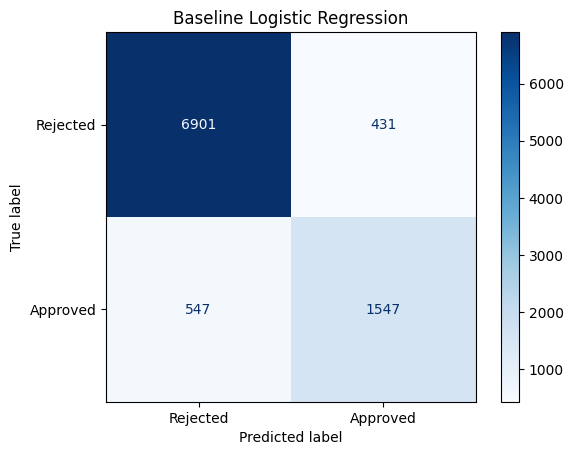

Accuracy:  0.8962
Precision: 0.7821
Recall / Sensitivity / True Positive Rate (TPR): 0.7388
Specificity / True Negative Rate (TNR): 0.9412
F1 Score:  0.7598


In [64]:
# dropping a column for LR (person experience) tp avoid multiconerality:
cm = confusion_matrix(y_test, lr_base2_pred)
ConfusionMatrixDisplay(cm, display_labels=['Rejected', 'Approved']).plot(cmap='Blues')
plt.title('Baseline Logistic Regression')
plt.show()

print(f'Accuracy:  {accuracy_score(y_test, lr_base2_pred):.4f}')
print(f'Precision: {precision_score(y_test, lr_base2_pred):.4f}')
print(f'Recall / Sensitivity / True Positive Rate (TPR): {recall_score(y_test, lr_base2_pred):.4f}')
specificity = recall_score(y_test, lr_base2_pred, pos_label=0)
print(f'Specificity / True Negative Rate (TNR): {specificity:.4f}')
print(f'F1 Score:  {f1_score(y_test, lr_base2_pred):.4f}')

results.append({
    'Model':     'Baseline Logistic Regression',
    'Accuracy':  accuracy_score(y_test, lr_base2_pred),
    'Precision': precision_score(y_test, lr_base2_pred),
    'Recall':    recall_score(y_test, lr_base2_pred),
    'F1':        f1_score(y_test, lr_base2_pred)
})

Fitting 5 folds for each of 52 candidates, totalling 260 fits


C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Parameters:
{'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Best Cross-Validation F1:
0.7627


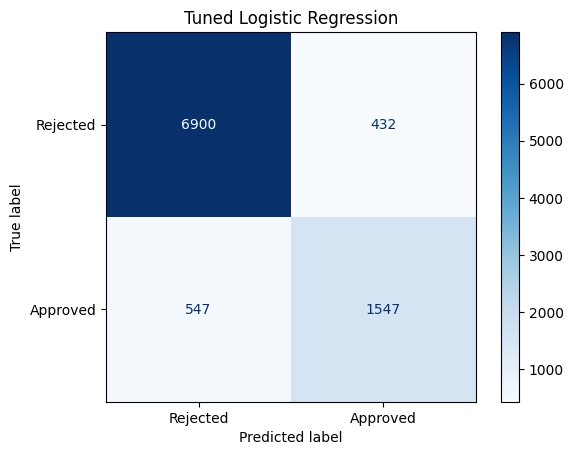

Accuracy:  0.8961
Precision: 0.7817
Recall / Sensitivity / TPR: 0.7388
Specificity / TNR: 0.9411
F1 Score:  0.7596


In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ---------------------------------------------------
# Logistic Regression Pipeline
# ---------------------------------------------------

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=42,
        max_iter=2000
    ))
])

# ---------------------------------------------------
# Hyperparameter Grid
# ---------------------------------------------------

param_grid = {

    'model__C': [
        0.001,
        0.01,
        0.1,
        0.5,
        1,
        2,
        5,
        10,
        20,
        30,
        50,
        70,
        100
    ],

    'model__penalty': [
        'l1',
        'l2'
    ],

    'model__solver': [
        'liblinear'
    ],

    'model__class_weight': [
        None,
        'balanced'
    ]
}

# ---------------------------------------------------
# Cross Validation
# ---------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ---------------------------------------------------
# Grid Search
# ---------------------------------------------------

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

# ---------------------------------------------------
# Best Model
# ---------------------------------------------------

print("Best Parameters:")
print(lr_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(f"{lr_grid.best_score_:.4f}")

# ---------------------------------------------------
# Predictions
# ---------------------------------------------------

best_lr = lr_grid.best_estimator_

y_pred = best_lr.predict(X_test)

# ---------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    cm,
    display_labels=['Rejected', 'Approved']
).plot(cmap='Blues')

plt.title('Tuned Logistic Regression')
plt.show()

# ---------------------------------------------------
# Metrics
# ---------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

specificity = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

f1 = f1_score(y_test, y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall / Sensitivity / TPR: {recall:.4f}')
print(f'Specificity / TNR: {specificity:.4f}')
print(f'F1 Score:  {f1:.4f}')

# ---------------------------------------------------
# Save Results
# ---------------------------------------------------

results.append({
    'Model': 'Tuned Logistic Regression',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1': f1
})

In [66]:
y_prob = best_lr.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.9523


In [67]:
# Predictions

lr_base2_pred = lr_base2.predict(X_test_scaled)

lr_tuned2_pred = best_lr.predict(X_test)

# Comparison Table

lr_results2 = pd.DataFrame([
    {
        'Model':       'Baseline LR (No Emp Exp)',
        'Accuracy':    accuracy_score(y_test, lr_base2_pred),
        'Precision':   precision_score(y_test, lr_base2_pred),
        'Recall':      recall_score(y_test, lr_base2_pred),
        'Specificity': recall_score(y_test, lr_base2_pred, pos_label=0),
        'F1':          f1_score(y_test, lr_base2_pred)
    },
    {
        'Model':       'Tuned LR (No Emp Exp)',
        'Accuracy':    accuracy_score(y_test, lr_tuned2_pred),
        'Precision':   precision_score(y_test, lr_tuned2_pred),
        'Recall':      recall_score(y_test, lr_tuned2_pred),
        'Specificity': recall_score(y_test, lr_tuned2_pred, pos_label=0),
        'F1':          f1_score(y_test, lr_tuned2_pred)
    }
]).set_index('Model')

lr_results2.style \
    .highlight_max(axis=0, color='#c8f7c5') \
    .highlight_min(axis=0, color='#f7c5c5') \
    .format("{:.4f}") \
    .set_caption("Logistic Regression (Without person_emp_exp) — Baseline vs Tuned") \
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'),
                   ('font-weight', 'bold'),
                   ('padding-bottom', '10px')]},
        {'selector': 'th',
         'props': [('background-color', '#f0f0f0'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('text-align', 'center'),
                   ('padding', '6px 12px')]}
    ])

,Accuracy,Precision,Recall,Specificity,F1
Model,,,,,
Baseline LR (No Emp Exp),0.8962,0.7821,0.7388,0.9412,0.7598
Tuned LR (No Emp Exp),0.8961,0.7817,0.7388,0.9411,0.7596


In [68]:
# Predict using the best pipeline
lr_tuned2_pred = lr_tuned2.best_estimator_.predict(X_test)

cm = confusion_matrix(y_test, lr_tuned2_pred)

ConfusionMatrixDisplay(
    cm,
    display_labels=['Rejected', 'Approved']
).plot(cmap='Blues')

plt.title('Tuned LR 2 — Balanced Precision & Recall')
plt.show()

print(f"Accuracy:    {accuracy_score(y_test, lr_tuned2_pred):.4f}")
print(f"Precision:   {precision_score(y_test, lr_tuned2_pred):.4f}")
print(f"Recall:      {recall_score(y_test, lr_tuned2_pred):.4f}")
print(f"Specificity: {recall_score(y_test, lr_tuned2_pred, pos_label=0):.4f}")
print(f"F1 Score:    {f1_score(y_test, lr_tuned2_pred):.4f}")

results.append({
    'Model':     'Tuned LR 2 (Balanced P&R)',
    'Accuracy':  accuracy_score(y_test, lr_tuned2_pred),
    'Precision': precision_score(y_test, lr_tuned2_pred),
    'Recall':    recall_score(y_test, lr_tuned2_pred),
    'F1':        f1_score(y_test, lr_tuned2_pred)
})

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- person_emp_exp


In [ ]:
# Predict using Baseline LR (without person_emp_exp)

lr_base2_pred = lr_base2.predict(X_test_scaled)

cm = confusion_matrix(y_test, lr_base2_pred)

ConfusionMatrixDisplay(
    cm,
    display_labels=['Rejected', 'Approved']
).plot(cmap='Blues')

plt.title('Baseline LR (No Emp Exp)')
plt.show()

print(f"Accuracy:    {accuracy_score(y_test, lr_base2_pred):.4f}")
print(f"Precision:   {precision_score(y_test, lr_base2_pred):.4f}")
print(f"Recall:      {recall_score(y_test, lr_base2_pred):.4f}")
print(f"Specificity: {recall_score(y_test, lr_base2_pred, pos_label=0):.4f}")
print(f"F1 Score:    {f1_score(y_test, lr_base2_pred):.4f}")

results.append({
    'Model':     'Baseline LR (No Emp Exp)',
    'Accuracy':  accuracy_score(y_test, lr_base2_pred),
    'Precision': precision_score(y_test, lr_base2_pred),
    'Recall':    recall_score(y_test, lr_base2_pred),
    'F1':        f1_score(y_test, lr_base2_pred)
})